# Catan Resource Analysis: Probability, Settlement EV, and Monte Carlo Simulation

> *Catan is a probability game disguised as a trading game.*

Every strategic decision in Catan rests on two dice. Understanding that distribution
and how settlement placement maps onto it is the foundation of good play.

This notebook works through three layers of analysis using `dice.py`, `board.py`,
and `simulator.py`:

1. **Dice fundamentals**: exact probabilities, pip values, cumulative resource curves
2. **Settlement analysis**: expected value and diversity across all vertices
3. **Monte Carlo simulation**: what does the full distribution look like, not just the mean?

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import dice  as dc
import board as bd
import simulator as sim

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0d1b2a",
    "axes.facecolor":   "#0d1b2a",
    "text.color":       "#dde8f0",
    "axes.edgecolor":   "#2a4a6a",
    "axes.labelcolor":  "#dde8f0",
    "xtick.color":      "#dde8f0",
    "ytick.color":      "#dde8f0",
    "grid.color":       "#1e3040",
    "grid.linestyle":   "--",
    "grid.alpha":       0.4,
})
# print("dice.py      :", dc.__file__)
# print("board.py     :", bd.__file__)
# print("simulator.py :", sim.__file__)
print("Imports complete")

Imports complete


## Two-Dice Probability Fundamentals

The entire strategic framework of Catan rests on one distribution: two six-sided
dice summed together. It is triangular, peaked at 7, and 7
itself triggers the robber rather than producing resources.

**Pip values** encode this visually. A tile numbered 6 shows 5 dots because there
are 5 ways to roll 6 with 2d6. A tile numbered 2 shows 1 dot because there is
only 1 way to roll 2.

In [2]:
# Call the probability table
dc.print_probability_table()

 Roll   Ways   Probability   Pips        %
    2      1          1/36      ·    2.78%
    3      2          1/18     ··    5.56%
    4      3          1/12    ···    8.33%
    5      4           1/9   ····   11.11%
    6      5          5/36  ·····   13.89%
    7      6           1/6  ······   16.67% ← robber
    8      5          5/36  ·····   13.89%
    9      4           1/9   ····   11.11%
   10      3          1/12    ···    8.33%
   11      2          1/18     ··    5.56%
   12      1          1/36      ·    2.78%
─────────────────────────────────────────────
Total     36         36/36         100.00%


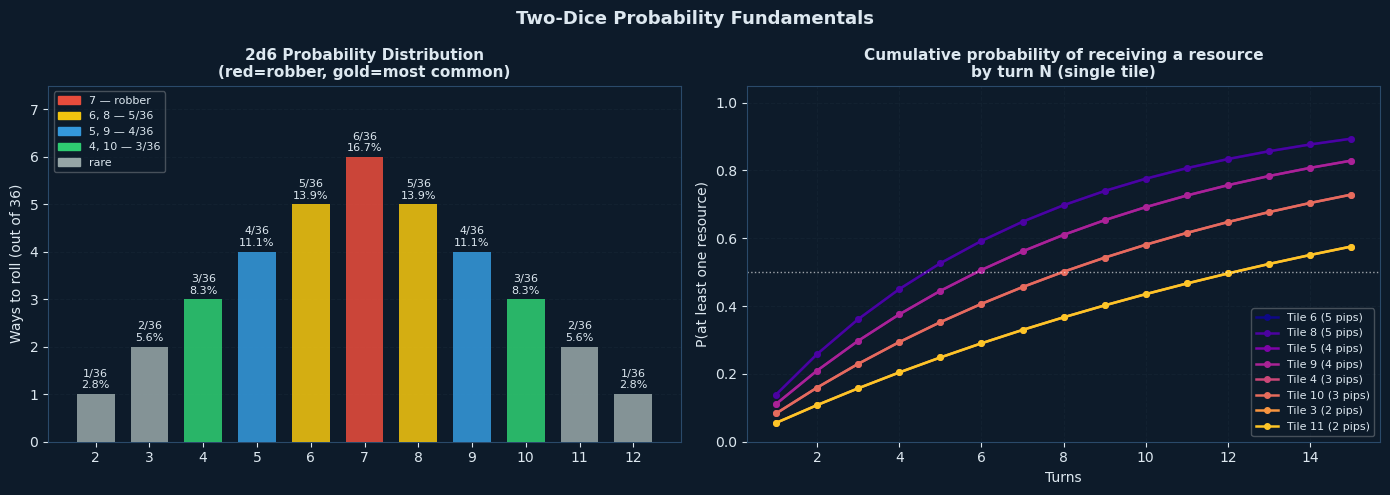

In [3]:
rolls = list(range(2, 13))
ways  = [dc.PIP_VALUE[n] for n in rolls]
probs = [float(dc.ROLL_PROBABILITY[n]) * 100 for n in rolls]

ROLL_COLORS = [
    "#e74c3c" if n == 7 else
    "#f1c40f" if n in (6, 8) else
    "#3498db" if n in (5, 9) else
    "#2ecc71" if n in (4, 10) else
    "#95a5a6"
    for n in rolls
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(rolls, ways, color=ROLL_COLORS, alpha=0.88, width=0.7, zorder=3)
for bar, w, p in zip(bars, ways, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f"{w}/36\n{p:.1f}%", ha="center", va="bottom", fontsize=8,
            color="#dde8f0")
ax.set_xticks(rolls)
ax.set_ylabel("Ways to roll (out of 36)")
ax.set_title("2d6 Probability Distribution\n(red=robber, gold=most common)",
             fontsize=11, fontweight="bold")
ax.set_ylim(0, 7.5)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color="#e74c3c", label="7 — robber"),
    mpatches.Patch(color="#f1c40f", label="6, 8 — 5/36"),
    mpatches.Patch(color="#3498db", label="5, 9 — 4/36"),
    mpatches.Patch(color="#2ecc71", label="4, 10 — 3/36"),
    mpatches.Patch(color="#95a5a6", label="rare"),
], fontsize=8, loc="upper left", framealpha=0.3)

ax = axes[1]
tile_numbers = [6, 8, 5, 9, 4, 10, 3, 11]
turn_range   = range(1, 16)
for i, tile in enumerate(tile_numbers):
    p_vals = [dc.probability_of_at_least_one_resource([tile], t) for t in turn_range]
    color  = plt.cm.plasma(i / len(tile_numbers))
    ax.plot(turn_range, p_vals, "o-", color=color, linewidth=1.8,
            markersize=4, label=f"Tile {tile} ({dc.PIP_VALUE[tile]} pips)")
ax.axhline(0.5, color="white", linewidth=1, linestyle=":", alpha=0.6)
ax.set_xlabel("Turns"); ax.set_ylabel("P(at least one resource)")
ax.set_title("Cumulative probability of receiving a resource\nby turn N (single tile)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.3)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

plt.suptitle("Two-Dice Probability Fundamentals", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Settlement EV Analysis
A settlement's expected value per turn is the sum of its adjacent tile probabilities.
A vertex touching tiles 6, 8, and 9 earns `5/36 + 5/36 + 4/36 = 14/36 ≈ 0.389 resources/turn`.

EV alone doesn't tell the full story. A settlement with high EV on one resource type
forces you to trade for everything else. **Resource diversity** is the tradeoff.

In [4]:
# Print settlement table
bd.print_settlement_table(n=26)


Rank  Vertex   EV/turn   Pips             Tiles  Resources
──────────────────────────────────────────────────────────────────────
   1      A6    0.3333     12             9+6+4  lumber, brick, wool
   2      B2    0.3056     11            6+9+11  brick, wheat, lumber
   3      C1    0.3056     11            9+11+8  wheat, lumber, lumber
   4      C5    0.3056     11             3+8+5  lumber, ore, wool
   5      D1    0.3056     11             8+3+5  lumber, ore, brick
   6      D2    0.3056     11             3+5+6  ore, brick, wheat
   7      A5    0.2778     10             2+9+6  wool, lumber, brick
   8      B1    0.2778     10            12+6+9  wheat, brick, wheat
   9      B3    0.2778     10            6+4+11  brick, wool, lumber
  10      D3    0.2778     10             3+4+6  ore, wheat, wheat
  11      D4    0.2778     10            4+6+11  wheat, wheat, wool
  12      C3    0.2500      9            11+8+3  lumber, lumber, ore
  13      C6    0.2500      9             3+4+

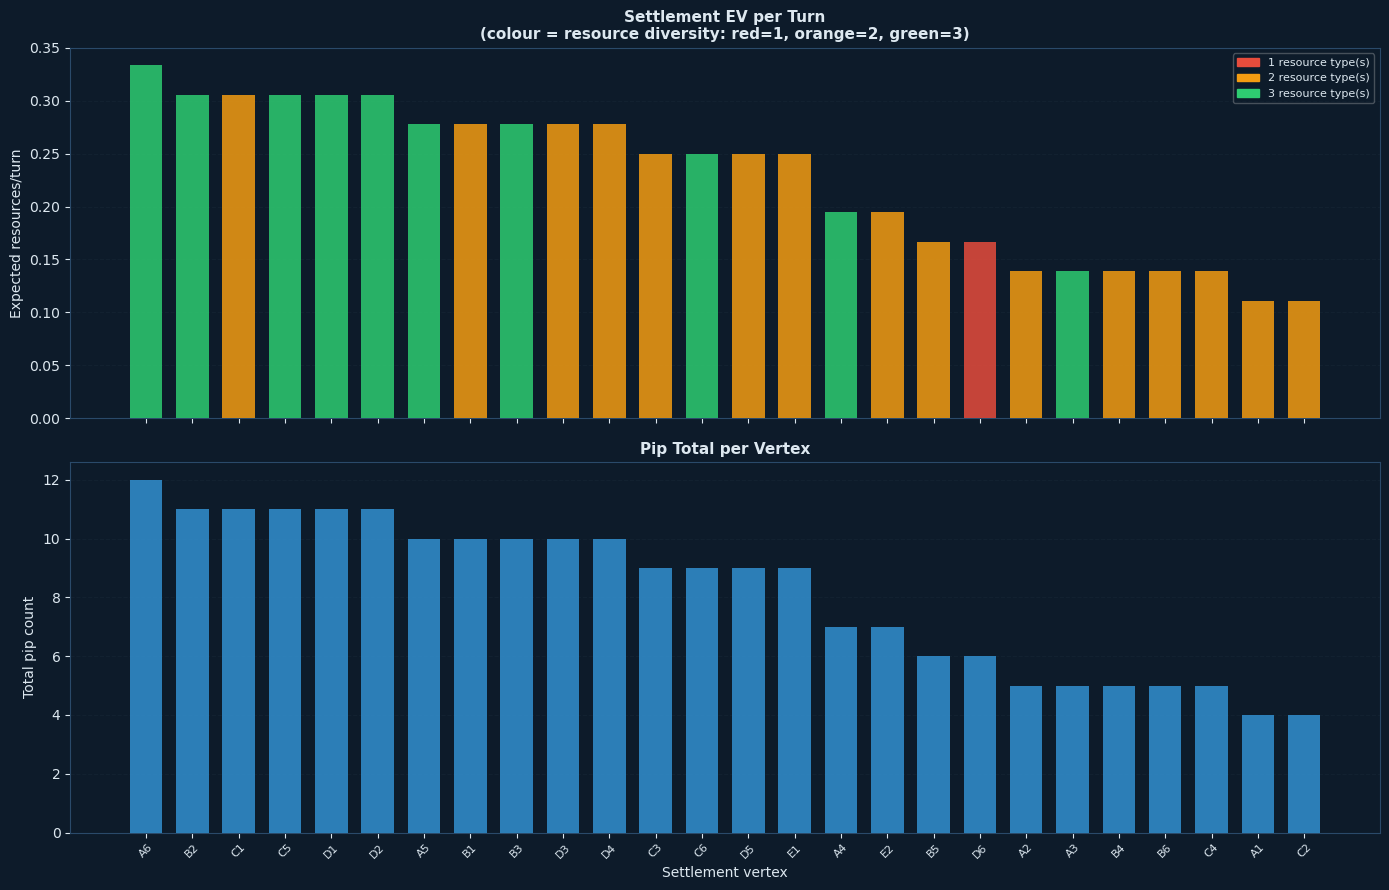

Top 5:
  1. A6  EV=0.3333  pips=12  tiles=[9+6+4]  resources=['lumber', 'brick', 'wool']
  2. B2  EV=0.3056  pips=11  tiles=[6+9+11]  resources=['brick', 'wheat', 'lumber']
  3. C1  EV=0.3056  pips=11  tiles=[9+11+8]  resources=['wheat', 'lumber', 'lumber']
  4. C5  EV=0.3056  pips=11  tiles=[3+8+5]  resources=['lumber', 'ore', 'wool']
  5. D1  EV=0.3056  pips=11  tiles=[8+3+5]  resources=['lumber', 'ore', 'brick']


In [5]:
all_s   = sorted(bd.SETTLEMENTS, key=lambda s: s.ev, reverse=True)
names   = [s.name for s in all_s]
evs     = [s.ev   for s in all_s]
divs    = [s.resource_diversity for s in all_s]
pips    = [s.pip_total for s in all_s]

DIV_COLORS = {1:"#e74c3c", 2:"#f39c12", 3:"#2ecc71"}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.bar(names, evs,
       color=[DIV_COLORS.get(d,"#95a5a6") for d in divs],
       alpha=0.85, width=0.7, zorder=3)
ax.set_ylabel("Expected resources/turn")
ax.set_title("Settlement EV per Turn\n(colour = resource diversity: red=1, orange=2, green=3)",
             fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=[mpatches.Patch(color=c, label=f"{k} resource type(s)")
                   for k, c in DIV_COLORS.items()],
          fontsize=8, framealpha=0.3)

ax = axes[1]
ax.bar(names, pips, color="#3498db", alpha=0.8, width=0.7, zorder=3)
ax.set_ylabel("Total pip count")
ax.set_title("Pip Total per Vertex", fontsize=11, fontweight="bold")
ax.set_xlabel("Settlement vertex")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

print("Top 5:")
for i, s in enumerate(all_s[:5], 1):
    tiles = "+".join(str(n) for n in s.tile_numbers)
    print(f"  {i}. {s.name}  EV={s.ev:.4f}  pips={s.pip_total}  "
          f"tiles=[{tiles}]  resources={s.resources}")

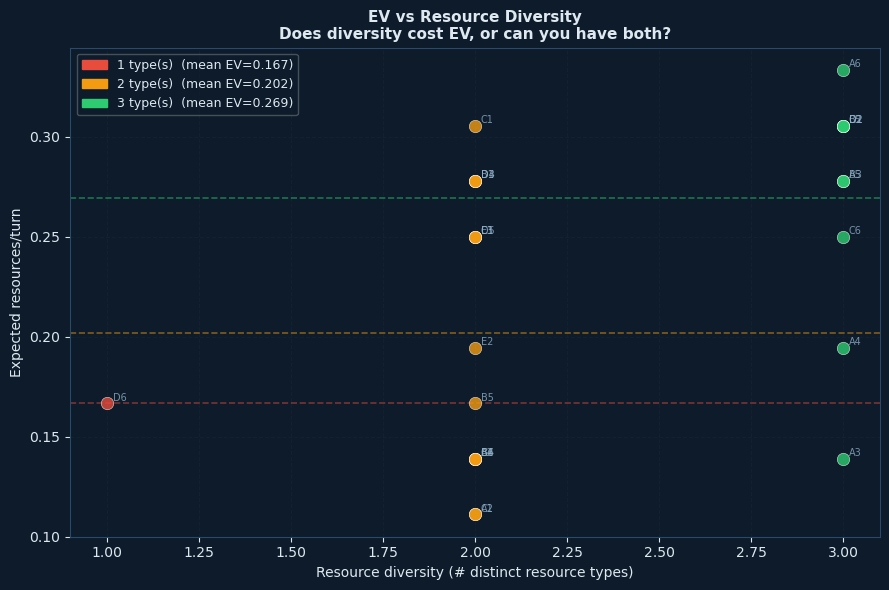

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
DIV_COLORS = {1:"#e74c3c", 2:"#f39c12", 3:"#2ecc71"}
means_by_div = {}

for s in bd.SETTLEMENTS:
    color = DIV_COLORS.get(s.resource_diversity, "#95a5a6")
    ax.scatter(s.resource_diversity, s.ev,
               color=color, s=80, alpha=0.8, zorder=3,
               edgecolors="white", linewidth=0.4)
    ax.annotate(s.name, (s.resource_diversity, s.ev),
                textcoords="offset points", xytext=(4,2),
                fontsize=7, color="#90b0c8", alpha=0.8)

for d in [1, 2, 3]:
    evs_d = [s.ev for s in bd.SETTLEMENTS if s.resource_diversity == d]
    if evs_d:
        means_by_div[d] = np.mean(evs_d)
        ax.axhline(means_by_div[d], color=DIV_COLORS[d],
                   linewidth=1.2, linestyle="--", alpha=0.5)

ax.set_xlabel("Resource diversity (# distinct resource types)")
ax.set_ylabel("Expected resources/turn")
ax.set_title("EV vs Resource Diversity\nDoes diversity cost EV, or can you have both?",
             fontsize=11, fontweight="bold")
ax.legend(handles=[mpatches.Patch(color=c,
          label=f"{k} type(s)  (mean EV={means_by_div.get(k,0):.3f})")
          for k, c in DIV_COLORS.items()],
          fontsize=9, framealpha=0.3)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Monte Carlo Simulation
Expected value describes the average outcome. Simulation reveals the *distribution*
of outcomes i.e. how often you fall far below or above that average across a real game.

500 games, 60 turns each, for the top 8 settlement positions.

In [7]:
cfg  = sim.SimulationConfig(n_games=500, n_turns=60, seed=42)
top8 = bd.top_settlements(8)

print("Running simulations (500 games x 60 turns x 8 settlements)...")
df_compare = sim.compare_settlements(top8, cfg)
print()
print(df_compare[[
    "vertex","tiles","pip_total","ev_per_turn",
    "mean_total","std_total","p10","p50","p90","drought_rate_%"
]].to_string(index=False))

Running simulations (500 games x 60 turns x 8 settlements)...

vertex  tiles  pip_total  ev_per_turn  mean_total  std_total  p10  p50  p90  drought_rate_%
    A6  9+6+4         12       0.3333       20.04       3.66 15.0 20.0 24.0            97.0
    D2  3+5+6         11       0.3056       18.25       3.64 14.0 18.0 23.0            98.2
    B2 6+9+11         11       0.3056       18.23       3.38 14.0 18.0 23.0            98.4
    C5  3+8+5         11       0.3056       18.13       3.65 14.0 18.0 23.0            99.4
    D1  8+3+5         11       0.3056       18.13       3.65 14.0 18.0 23.0            99.4
    C1 9+11+8         11       0.3056       18.11       3.73 13.9 18.0 23.0            98.6
    B1 12+6+9         10       0.2778       16.59       3.36 12.9 17.0 21.0            99.6
    A5  2+9+6         10       0.2778       16.58       3.42 12.0 16.0 21.0            99.0


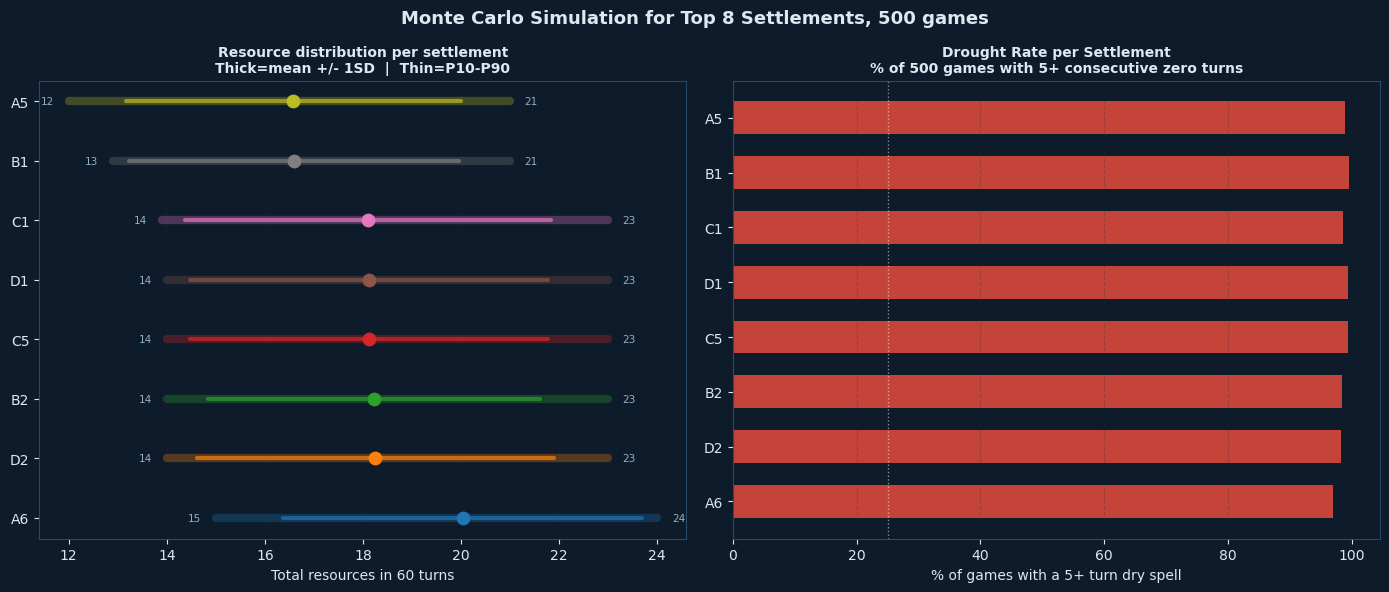

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap  = plt.cm.tab10
names = df_compare["vertex"].tolist()
means = df_compare["mean_total"].tolist()
stds  = df_compare["std_total"].tolist()
p10s  = df_compare["p10"].tolist()
p90s  = df_compare["p90"].tolist()

ax = axes[0]
colors = [cmap(i / len(names)) for i in range(len(names))]
for i, (name, mean, std, p10, p90, color) in enumerate(
        zip(names, means, stds, p10s, p90s, colors)):
    ax.plot([p10, p90], [i, i], color=color, linewidth=6,
            alpha=0.3, solid_capstyle="round")
    ax.plot([mean-std, mean+std], [i, i], color=color, linewidth=3,
            alpha=0.7, solid_capstyle="round")
    ax.scatter([mean], [i], color=color, s=80, zorder=5)
    ax.text(p10 - 0.3, i, f"{p10:.0f}", va="center", ha="right",
            fontsize=7.5, color="#90b0c8")
    ax.text(p90 + 0.3, i, f"{p90:.0f}", va="center", ha="left",
            fontsize=7.5, color="#90b0c8")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel("Total resources in 60 turns")
ax.set_title("Resource distribution per settlement\nThick=mean +/- 1SD  |  Thin=P10-P90",
             fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
drought_rates = df_compare["drought_rate_%"].tolist()
bar_colors = ["#e74c3c" if r>40 else "#f39c12" if r>20 else "#2ecc71"
              for r in drought_rates]
ax.barh(names, drought_rates, color=bar_colors, alpha=0.85, height=0.6)
ax.axvline(25, color="white", linewidth=1, linestyle=":", alpha=0.5)
ax.set_xlabel("% of games with a 5+ turn dry spell")
ax.set_title("Drought Rate per Settlement\n% of 500 games with 5+ consecutive zero turns",
             fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.25)

plt.suptitle("Monte Carlo Simulation for Top 8 Settlements, 500 games",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

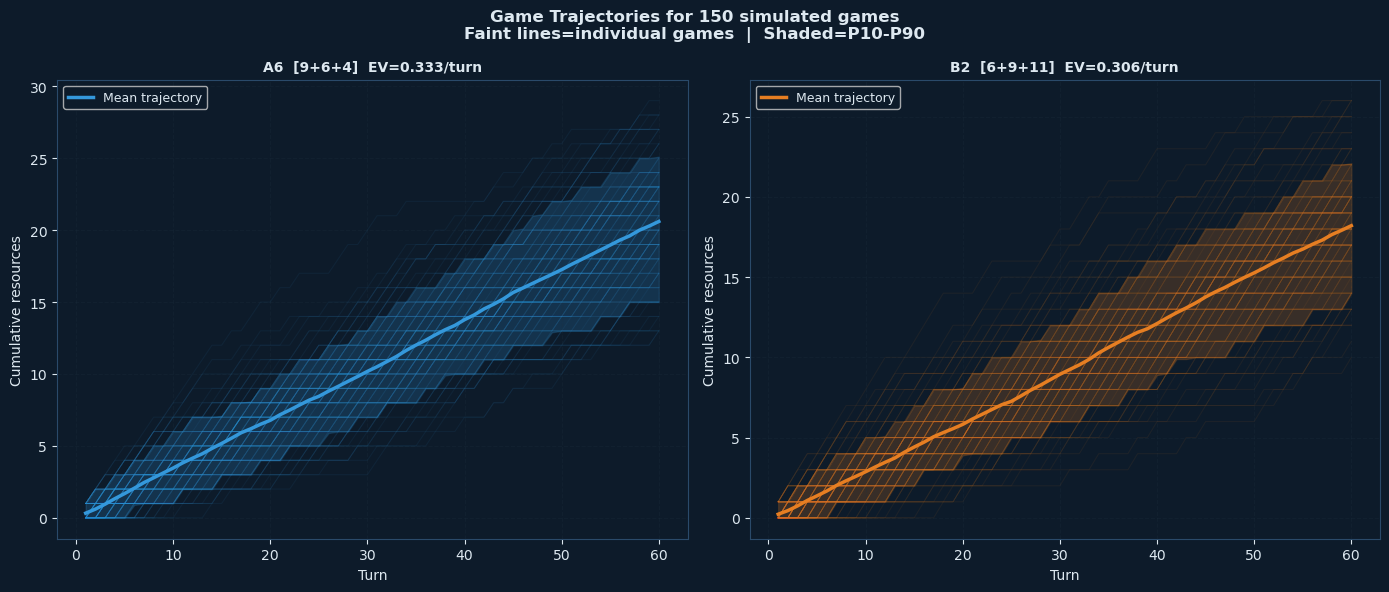

In [13]:
# Game trajectories for the best two settlements in the top 8
best   = top8[0]
second = top8[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, settlement, color in zip(axes, [best, second], ["#3498db","#e67e22"]):
    df = sim.simulate_settlement(
        settlement,
        sim.SimulationConfig(n_games=150, n_turns=60, seed=42)
    )
    for game_id in df["game"].unique():
        gdf = df[df["game"] == game_id]
        ax.plot(gdf["turn"], gdf["cumulative_resources"],
                color=color, alpha=0.07, linewidth=0.8)

    mean_traj = df.groupby("turn")["cumulative_resources"].mean()
    p10_traj  = df.groupby("turn")["cumulative_resources"].quantile(0.10)
    p90_traj  = df.groupby("turn")["cumulative_resources"].quantile(0.90)
    ax.fill_between(mean_traj.index, p10_traj, p90_traj, color=color, alpha=0.2)
    ax.plot(mean_traj.index, mean_traj, color=color, linewidth=2.5,
            label="Mean trajectory")

    tiles = "+".join(str(n) for n in settlement.tile_numbers)
    ax.set_title(f"{settlement.name}  [{tiles}]  EV={settlement.ev:.3f}/turn",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Turn"); ax.set_ylabel("Cumulative resources")
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.suptitle("Game Trajectories for 150 simulated games\n"
             "Faint lines=individual games  |  Shaded=P10-P90",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## Robber Impact
The robber blocks one tile entirely for however many turns it sits there.
The cost is losing a 6-tile costs far more than losing a 3-tile,
even from the same settlement.

ROBBER IMPACT on A6  (tiles: [9, 6, 4])
Baseline EV per 60-turn game: 20.00 resources

    Tile   Loss/game    % of EV lost   Pip value
       6       8.380           41.9%           5
       9       6.546           32.7%           4
       4       5.112           25.6%           3


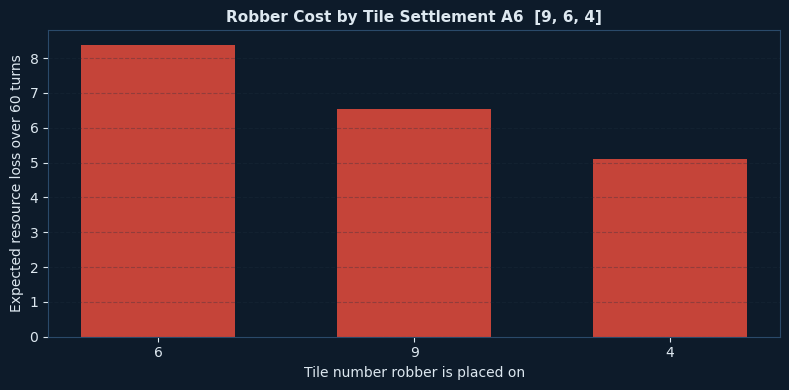

In [10]:
target     = top8[0]
cfg_robber = sim.SimulationConfig(n_games=500, n_turns=60, seed=42)
impact     = sim.robber_impact_analysis(target, cfg_robber)

baseline_total = target.ev * 60
print(f"ROBBER IMPACT on {target.name}  (tiles: {target.tile_numbers})")
print(f"Baseline EV per 60-turn game: {baseline_total:.2f} resources")
print()
print(f"  {'Tile':>6}  {'Loss/game':>10}  {'% of EV lost':>14}  {'Pip value':>10}")
for tile_num in sorted(impact, key=lambda n: -impact[n]):
    loss = impact[tile_num]
    print(f"  {tile_num:>6}  {loss:>10.3f}  {loss/baseline_total*100:>13.1f}%"
          f"  {dc.PIP_VALUE.get(tile_num,0):>10}")

fig, ax = plt.subplots(figsize=(8, 4))
tiles_sorted = sorted(impact, key=lambda n: -impact[n])
losses  = [impact[n] for n in tiles_sorted]
colors  = ["#e74c3c" if l>3 else "#f39c12" if l>1.5 else "#2ecc71" for l in losses]
ax.bar([str(t) for t in tiles_sorted], losses, color=colors, alpha=0.85, width=0.6)
ax.set_xlabel("Tile number robber is placed on")
ax.set_ylabel("Expected resource loss over 60 turns")
ax.set_title(f"Robber Cost by Tile Settlement {target.name}  {target.tile_numbers}",
             fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Dry Spell Probability
How likely is a drought of length k? We can approximate analytically and
compare to simulation to see where the approximation holds.

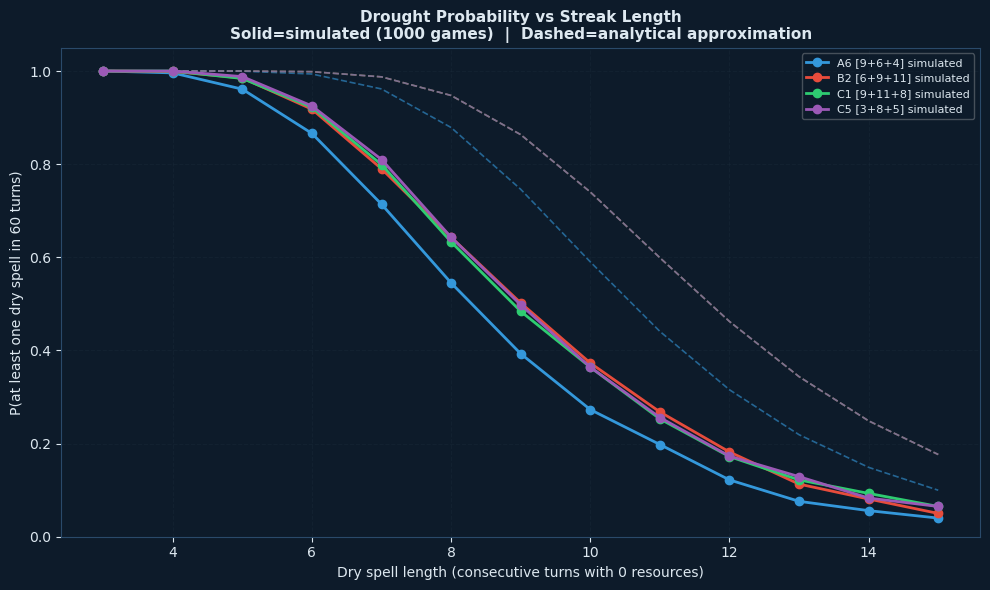

In [11]:
def p_dry_spell_approx(tile_numbers, k, turns=60):
    p_miss     = 1.0 - dc.expected_resources_per_turn(tile_numbers)
    p_window   = p_miss ** k
    n_windows  = turns - k + 1
    return 1.0 - (1.0 - p_window) ** n_windows

fig, ax = plt.subplots(figsize=(10, 6))
streak_lengths = range(3, 16)
cfg_ds = sim.SimulationConfig(n_games=1000, n_turns=60, seed=7)
colors = ["#3498db","#e74c3c","#2ecc71","#9b59b6"]

for settlement, color in zip(top8[:4], colors):
    df = sim.simulate_settlement(settlement, cfg_ds)
    sim_rates = []
    for k in streak_lengths:
        drought_count = 0
        for g in range(cfg_ds.n_games):
            gdf = df[df["game"] == g]["resource_earned"].tolist()
            count = 0
            for v in gdf:
                count = count + 1 if v == 0 else 0
                if count >= k:
                    drought_count += 1
                    break
        sim_rates.append(drought_count / cfg_ds.n_games)

    ana_rates = [p_dry_spell_approx(settlement.tile_numbers, k) for k in streak_lengths]
    tiles = "+".join(str(n) for n in settlement.tile_numbers)
    ax.plot(streak_lengths, sim_rates, "o-", color=color, linewidth=2,
            label=f"{settlement.name} [{tiles}] simulated")
    ax.plot(streak_lengths, ana_rates, "--", color=color, linewidth=1.2, alpha=0.6)

ax.set_xlabel("Dry spell length (consecutive turns with 0 resources)")
ax.set_ylabel("P(at least one dry spell in 60 turns)")
ax.set_title("Drought Probability vs Streak Length\n"
             "Solid=simulated (1000 games)  |  Dashed=analytical approximation",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Board Visualization
A rough spatial view of the board with settlement vertices colored by EV.
Greener dot = higher EV. The top 5 positions are highlighted with larger markers.

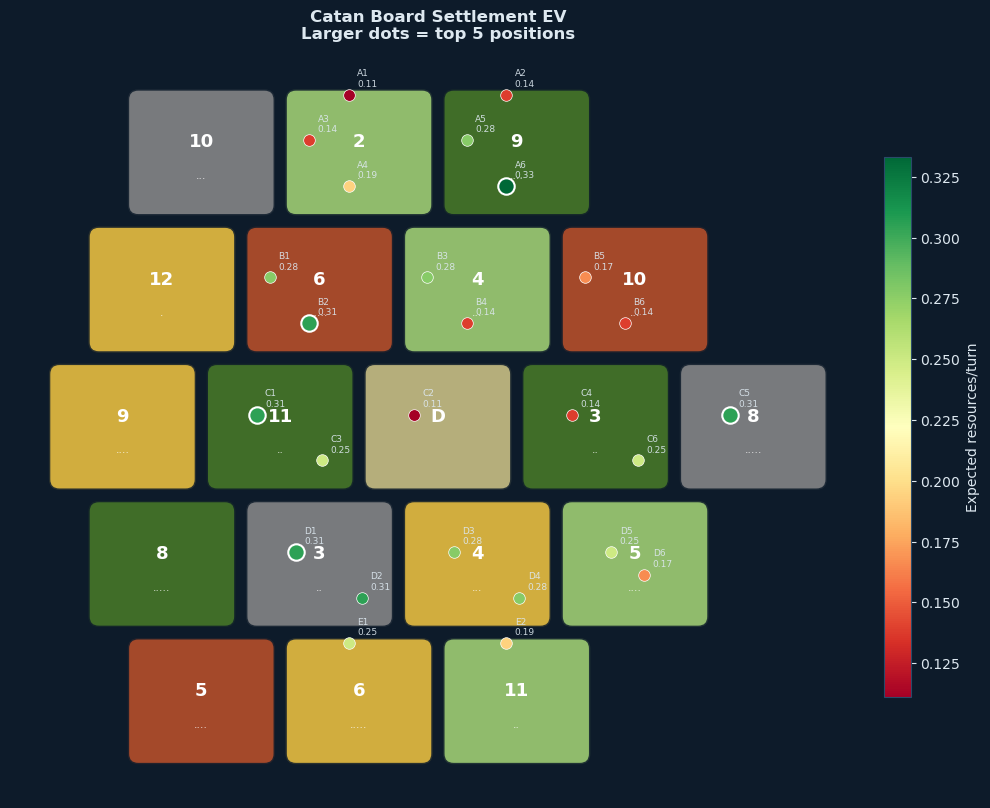

In [12]:
def draw_board(settlements, highlight=None, title="Catan Board Settlement EV"):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_facecolor("#0d1b2a")

    row_offsets = {0:1.0, 1:0.5, 2:0.0, 3:0.5, 4:1.0}
    HEX_SIZE = 1.5

    for h in bd.STANDARD_HEXES:
        xc = h.col * HEX_SIZE + row_offsets[h.row] * HEX_SIZE * 0.5
        yc = -h.row * HEX_SIZE * 0.87
        color = bd.RESOURCE_COLORS.get(h.resource, "#888")
        ax.add_patch(mpatches.FancyBboxPatch(
            (xc-0.6, yc-0.5), 1.2, 1.0, boxstyle="round,pad=0.1",
            facecolor=color, edgecolor="#0d1b2a", linewidth=2, alpha=0.85, zorder=1))
        ax.text(xc, yc+0.1, h.label, ha="center", va="center",
                fontsize=13, fontweight="bold", color="white", zorder=3)
        ax.text(xc, yc-0.22, "." * h.pip_value, ha="center", va="center",
                fontsize=8, color="white", alpha=0.8, zorder=3)

    evs   = [s.ev for s in settlements]
    ev_min, ev_max = min(evs), max(evs)
    cmap_s = plt.cm.RdYlGn

    for s in settlements:
        xs = [bd.hex_at(c,r).col * HEX_SIZE + row_offsets[r]*HEX_SIZE*0.5 + 0.65
              for c,r in s.hex_coords if bd.hex_at(c,r)]
        ys = [-bd.hex_at(c,r).row * HEX_SIZE*0.87 + 0.55
              for c,r in s.hex_coords if bd.hex_at(c,r)]
        if not xs: continue
        vx, vy = np.mean(xs), np.mean(ys)
        norm_ev = (s.ev - ev_min) / (ev_max - ev_min + 1e-9)
        is_hl   = highlight and s.name in highlight
        ax.scatter([vx], [vy], color=cmap_s(norm_ev),
                   s=140 if is_hl else 70, zorder=5,
                   edgecolors="white", linewidth=1.5 if is_hl else 0.5)
        ax.text(vx+0.08, vy+0.08, f"{s.name}\n{s.ev:.2f}",
                fontsize=6.5, color="#dde8f0", zorder=6, alpha=0.9)

    sm = plt.cm.ScalarMappable(cmap=cmap_s,
          norm=mcolors.Normalize(vmin=ev_min, vmax=ev_max))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02,
                 label="Expected resources/turn")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.autoscale(); plt.tight_layout(); plt.show()

top5_names = [s.name for s in bd.top_settlements(5)]
draw_board(bd.SETTLEMENTS, highlight=top5_names,
           title="Catan Board Settlement EV\nLarger dots = top 5 positions")

## Summary

| Question | Tool | Answer shape |
|---|---|---|
| P(rolling a 6)? | `dice.ROLL_PROBABILITY` | 5/36 ≈ 13.9% |
| Best settlement? | `board.top_settlements()` | Vertex with highest pip sum |
| Drought risk? | `simulator.compare_settlements()` | See `drought_rate_%` |
| Robber cost? | `simulator.robber_impact_analysis()` | Resources lost per blocked tile |
| Realistic outcome range? | P10–P90 from simulation | Depends on settlement variance |

### What to explore next

- **Multi-settlement**: model two settlements combined. Does a diverse second
  settlement reduce drought risk more than a high-EV duplicate resource?
- **Port optimization**: add 2:1 and 3:1 port modifiers to EV. A low-EV vertex
  on a 2:1 ore port may outperform a high-EV non-port position
- **Game length sensitivity**: rerun at 40, 60, and 80 turns. How much does
  settlement choice matter in shorter versus longer games?
- **Road building**: model the expected turns to reach a target vertex given
  dice rolls, and whether expanding early or late maximizes total yield